In [12]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import cv2
import json
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import Any

from project_root import PROJECT_ROOT,DATASETS_ROOT

import fiftyone as fo
import fiftyone.utils.torch as fout
from fiftyone import ViewField as F


import torchvision as tv

from scripts.model_serialization import load_model

no_grad_guard = torch.no_grad()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
###############################################
# This configures which model/dataset we are evaluating
# Identity
id_model_path = Path(
    "/home/dherrera/git/zoo_vision/models/identity/vit/good_freeze_embeddings4/config.ptc"
)
certainty_model_path = Path(
    "/home/dherrera/git/zoo_vision/models/certainty/vit/freeze_vit_v1/config.ptc"
)
datasets: dict[str, fo.Dataset] = {
    name: fo.load_dataset(name)
    for name in [
        # "zoo-elephants-identity-train",
        "zoo-elephants-identity-val",
        "zoo-elephants-identity-id3",
        "zoo-elephants-identity-tracks",
    ]
}


# ds = datasets["zoo-elephants-identity-id3"]
# session = fo.launch_app(ds, auto=False)
# session.open_tab()

###############################################

ds0 = next(datasets.values().__iter__())
classes = sorted(ds0.classes["ground_truth"])
print(classes)

Session launched. Run `session.show()` to open the App in a cell output.


<IPython.core.display.Javascript object>

['01_Chandra', '02_Indi', '03_Fahra', '04_Panang', '05_Thai']


In [14]:
# model_path = PROJECT_ROOT / "models/identity/freeze09/dense121_c5_identity2.pth"
id_model = load_model(id_model_path).to(torch.device("cuda"))
id_model.eval()
certainty_model = load_model(certainty_model_path).to(torch.device("cuda"))
certainty_model.eval()

RecursiveScriptModule(
  original_name=ViTForImageClassification
  (vit): RecursiveScriptModule(
    original_name=ViTModel
    (embeddings): RecursiveScriptModule(
      original_name=ViTEmbeddings
      (patch_embeddings): RecursiveScriptModule(
        original_name=ViTPatchEmbeddings
        (projection): RecursiveScriptModule(original_name=Conv2d)
      )
      (dropout): RecursiveScriptModule(original_name=Dropout)
    )
    (encoder): RecursiveScriptModule(
      original_name=ViTEncoder
      (layer): RecursiveScriptModule(
        original_name=ModuleList
        (0): RecursiveScriptModule(
          original_name=ViTLayer
          (attention): RecursiveScriptModule(
            original_name=ViTAttention
            (attention): RecursiveScriptModule(
              original_name=ViTSelfAttention
              (query): RecursiveScriptModule(original_name=Linear)
              (key): RecursiveScriptModule(original_name=Linear)
              (value): RecursiveScriptModule(origi

In [15]:
import PIL

import transformers

image_processor = transformers.AutoImageProcessor.from_pretrained(id_model_path.parent)
print(f"{image_processor.image_mean=}, {image_processor.image_std=}")


def transform_and_preprocess(image: PIL.Image):
    image = np.asarray(image)
    # image = tv.transforms.Resize([224,224])(image)
    image = image_processor.preprocess(image)["pixel_values"][0]
    image = torch.from_numpy(image)
    # image = image.permute([2,0,1])
    # raise RuntimeError(f"{type(image)}")
    # raise RuntimeError(f"type is {type(image)}, {str(image.shape)=}")
    return image


sample0 = next(ds0.iter_samples())
# sample0 = {
#     "filepath": "/media/dherrera/ElephantExternal/elephants/tracks/new/zag_elp_cam_019/000001/zag_elp_cam_019_20250125_220949_t1_221.png"
# }
im0 = PIL.Image.open(sample0["filepath"])
print(f"{transform_and_preprocess(im0).shape=}")
t0 = transform_and_preprocess(im0).unsqueeze(0).to(torch.device("cuda"))
r0 = id_model(t0)
print(f"{r0=}")
print(r0["logits"].shape)

image_processor.image_mean=[0.48500001430511475, 0.4560000002384186, 0.4059999883174896], image_processor.image_std=[0.2290000021457672, 0.2239999920129776, 0.22499999403953552]
transform_and_preprocess(im0).shape=torch.Size([3, 224, 224])
r0={'logits': tensor([[ 2.7848, -2.9263, -0.0174,  5.0016, -4.5938]], device='cuda:0',
       grad_fn=<AddmmBackward0>)}
torch.Size([1, 5])


In [ ]:
#####################################################################
# Certainty model
classes_certainty = ["bad_certainty", "good_certainty"]
config = fout.TorchImageModelConfig(
    {
        "entrypoint_fcn": lambda: certainty_model,
        "entrypoint_args": {},
        "output_processor": fout.ClassifierOutputProcessor(
            classes=classes_certainty, store_logits=True
        ),
        "classes": classes_certainty,
        "transforms": transform_and_preprocess,
        "image_min_dim": 224,
        "image_max_dim": 2048,
    }
)
fo_certainty_model = fout.TorchImageModel(config)

# Apply
print("Applying certainty model to samples...")
datasets.pop("all", "no_fail")
for name, ds_i in datasets.items():
    print(f"{name}...")
    ds_i.apply_model(fo_certainty_model, label_field="pred_certainty")

    ds_i_good = ds_i.filter_labels("pred_certainty", F("label").contains_str("good"))
    print(f"{name}: good quality = {len(ds_i_good)}/{len(ds_i)}")
    datasets[name] = ds_i_good

Applying certainty model to samples...
zoo-elephants-identity-val...
 100% |█████████████████| 187/187 [1.2s elapsed, 0s remaining, 216.1 samples/s]         
zoo-elephants-identity-id3...
 100% |█████████████████| 953/953 [4.6s elapsed, 0s remaining, 219.2 samples/s]      
zoo-elephants-identity-tracks...
 100% |███████████████| 4626/4626 [22.9s elapsed, 0s remaining, 191.4 samples/s]      
zoo-elephants-identity-val: good quality = 103/187
zoo-elephants-identity-id3: good quality = 541/953
zoo-elephants-identity-tracks: good quality = 475/4626


In [30]:
#####################################################################
# Id model
config = fout.TorchImageModelConfig(
    {
        "entrypoint_fcn": lambda: id_model,
        "entrypoint_args": {},
        "output_processor": fout.ClassifierOutputProcessor(
            classes=classes, store_logits=True
        ),
        "classes": classes,
        "transforms": transform_and_preprocess,
        "image_min_dim": 224,
        "image_max_dim": 2048,
    }
)
fo_model = fout.TorchImageModel(config)

print("Applying id model to samples...")
datasets.pop("all", "no_fail")
for name, ds_i in datasets.items():
    print(f"{name}...")
    ds_i.apply_model(fo_model, label_field="prediction")

Applying id model to samples...
zoo-elephants-identity-val...
 100% |█████████████████| 103/103 [907.1ms elapsed, 0s remaining, 113.5 samples/s]      
zoo-elephants-identity-id3...
 100% |█████████████████| 541/541 [2.8s elapsed, 0s remaining, 211.4 samples/s]      
zoo-elephants-identity-tracks...
 100% |█████████████████| 475/475 [2.6s elapsed, 0s remaining, 204.6 samples/s]      


In [ ]:
# Merge datasets
if fo.dataset_exists("temp"):
    fo.delete_dataset("temp")
ds_all = fo.Dataset("temp")
for ds_i in datasets.values():
    ds_all.merge_samples(ds_i)
datasets["all"] = ds_all

Dataset zoo-elephants-identity-val
{'01_Chandra': 9, '02_Indi': 9, '03_Fahra': 24, '04_Panang': 28, '05_Thai': 33}
{'01_Chandra': 7, '02_Indi': 21, '03_Fahra': 21, '04_Panang': 21, '05_Thai': 33}
              precision    recall  f1-score   support

  01_Chandra       0.86      0.67      0.75         9
     02_Indi       0.38      0.89      0.53         9
    03_Fahra       0.90      0.79      0.84        24
   04_Panang       0.86      0.64      0.73        28
     05_Thai       1.00      1.00      1.00        33

    accuracy                           0.82       103
   macro avg       0.80      0.80      0.77       103
weighted avg       0.87      0.82      0.83       103



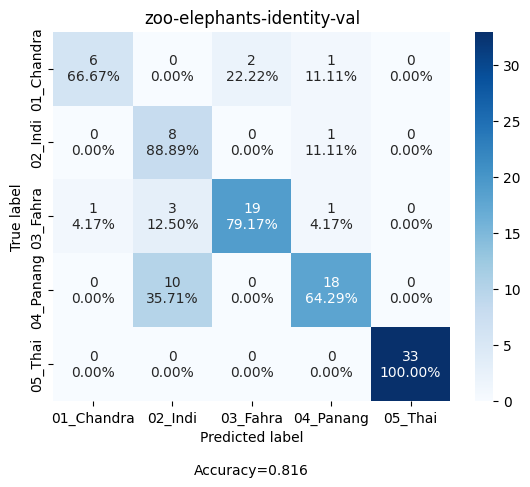

Dataset zoo-elephants-identity-id3
{'01_Chandra': 124, '02_Indi': 110, '03_Fahra': 101, '04_Panang': 118, '05_Thai': 88}
{'01_Chandra': 94, '02_Indi': 129, '03_Fahra': 113, '04_Panang': 117, '05_Thai': 88}
              precision    recall  f1-score   support

  01_Chandra       0.93      0.70      0.80       124
     02_Indi       0.76      0.89      0.82       110
    03_Fahra       0.76      0.85      0.80       101
   04_Panang       0.91      0.91      0.91       118
     05_Thai       0.98      0.98      0.98        88

    accuracy                           0.86       541
   macro avg       0.87      0.87      0.86       541
weighted avg       0.87      0.86      0.86       541



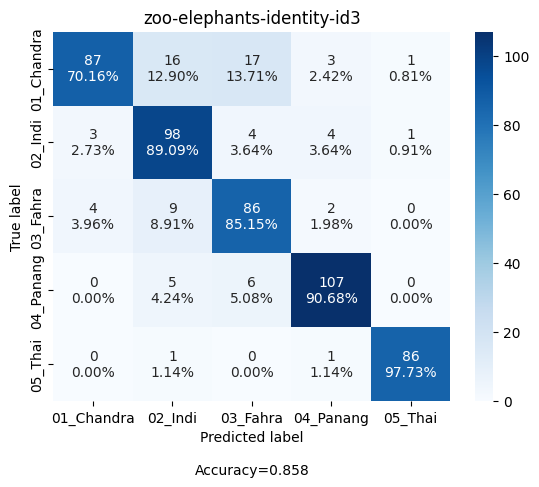

Dataset zoo-elephants-identity-tracks
{'01_Chandra': 95, '02_Indi': 185, '05_Thai': 195}
{'01_Chandra': 40, '02_Indi': 82, '03_Fahra': 96, '04_Panang': 55, '05_Thai': 202}
              precision    recall  f1-score   support

  01_Chandra       0.93      0.39      0.55        95
     02_Indi       0.89      0.39      0.55       185
    03_Fahra       0.00      0.00      0.00         0
   04_Panang       0.00      0.00      0.00         0
     05_Thai       0.90      0.93      0.92       195

    accuracy                           0.61       475
   macro avg       0.54      0.34      0.40       475
weighted avg       0.90      0.61      0.70       475



/home/dherrera/git/zoo_vision/scripts/cf_matrix.py:71: RuntimeWarning: invalid value encountered in divide
  ["{0:.2%}".format(value) for value in cf[r, :] / row_sum]


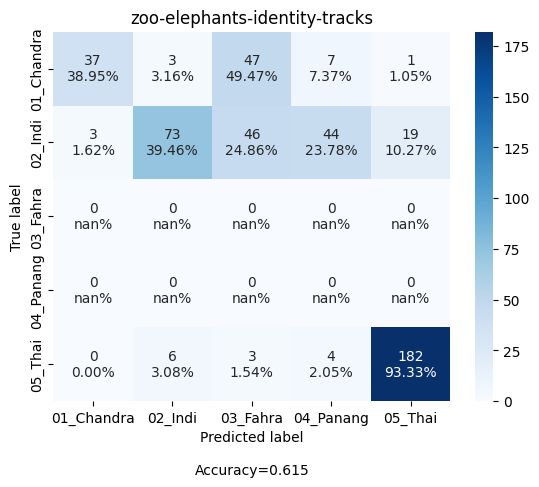

Dataset all
{'01_Chandra': 228, '02_Indi': 304, '03_Fahra': 125, '04_Panang': 146, '05_Thai': 316}
{'01_Chandra': 141, '02_Indi': 232, '03_Fahra': 230, '04_Panang': 193, '05_Thai': 323}
              precision    recall  f1-score   support

  01_Chandra       0.92      0.57      0.70       228
     02_Indi       0.77      0.59      0.67       304
    03_Fahra       0.46      0.84      0.59       125
   04_Panang       0.65      0.86      0.74       146
     05_Thai       0.93      0.95      0.94       316

    accuracy                           0.75      1119
   macro avg       0.75      0.76      0.73      1119
weighted avg       0.80      0.75      0.75      1119



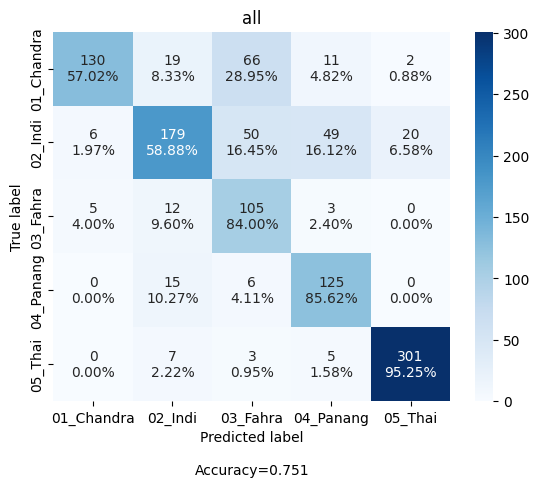

In [32]:
import seaborn as sns
from scripts.cf_matrix import make_confusion_matrix

for ds_i in datasets.values():
    ds_i.delete_evaluations()

for name, ds_i in datasets.items():
    print(f"Dataset {name}")
    ds_i.delete_evaluations()
    results = ds_i.evaluate_classifications(
        pred_field="prediction",
        gt_field="ground_truth",
        eval_key="eval",
        method="simple",
        classes=classes,
    )
    gt_counts = dict(sorted(ds_i.count_values("ground_truth.label").items()))
    pd_counts = dict(sorted(ds_i.count_values("prediction.label").items()))
    print(gt_counts)
    print(pd_counts)
    results.print_report()

    m = results.confusion_matrix()
    # sns.heatmap(m, annot=True,xticklabels=classes, yticklabels=classes, fmt="d")
    make_confusion_matrix(m, categories=classes)
    plt.gca().set_title(name)
    plt.show()

In [ ]:
ds = datasets["zoo-elephants-identity-tracks"]
session = fo.launch_app(ds, auto=False)

# session.view = (
#     ds
#     # .match_tags("validation")
#     .match(F("prediction.label") != F("ground_truth.label"))
#     # .sort_by("uniqueness", reverse=True)
# )
session.open_tab()

Session launched. Run `session.show()` to open the App in a cell output.


<IPython.core.display.Javascript object>